# Group-Scale Lens — BGG + Satellites

## Learning to Autolens / Examples / group_scale

---

**Problem.** A brightest-group-galaxy (BGG) at $z_L = 0.4$ + three satellites at the same redshift jointly deflect a source at $z_S = 1.8$. Unlike `compound_lens` (where deflectors live at *different* redshifts), here the entire lens plane is ONE plane — `al.Tracer` sums the deflection fields of all galaxies in that plane.

This is the bridge from galaxy-scale modelling (one lens, one source) toward cluster-scale lensing (hundreds of member galaxies). The pedagogical question: **when do you need to model satellite masses explicitly, and when can a single effective deflector + external shear do the job?**

**Method.** Two fit variants on the same mock:

1. **`bgg_shear_only`** — BGG with SIE mass + ExternalShear, satellites modelled only as *light* (no mass). ~15 free parameters.
2. **`bgg_plus_satellites`** — BGG (SIE) + 3 satellites with centres fixed at their photometric positions, each with a SIS mass (one free `einstein_radius` per satellite). ~25 free parameters.

Comparing `log_Z` between them quantifies whether the data resolve individual satellite masses.

**Prerequisites.** Mod 03, Mod 04, Examples/compound_lens (for the multi-galaxy setup pattern). The `extra_galaxies` API in `autolens_workspace_latest/scripts/imaging/features/extra_galaxies/modeling.py` is the direct reference for "fixed-centre satellite" modelling.


In [1]:
import os, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, IFrame, Markdown, display

import autofit as af
import autolens as al
import autolens.plot as aplt

%matplotlib inline
print(f"PyAutoLens version: {al.__version__}")

PyAutoLens version: 2026.4.13.6


In [2]:
RESULTS_ROOT = Path("results")

def show_result(stage_name):
    stage_dir = RESULTS_ROOT / stage_name
    if not stage_dir.exists():
        print(f"(no results for stage {stage_name!r})")
        return
    sp = stage_dir / "summary.json"
    if sp.exists():
        s = json.loads(sp.read_text())
        display(Markdown(
            f"### `{stage_name}`\n"
            f"- log evidence: **{s.get('log_evidence'):.2f}**\n"
            f"- χ²/N = **{s.get('chi_squared_per_pixel'):.3f}**\n"
            f"- max |normalized residual| = **{s.get('max_abs_normalized_residual'):.2f} σ**"
        ))
    fp = stage_dir / "fit_subplot.png"
    if fp.exists():
        display(Image(filename=str(fp)))

---
## 1. The data

A 160×160 HST-like cutout (larger than compound_lens / disky because the satellites are at ~2″ offsets from the BGG). The Einstein ring has **visible local kinks** at each satellite's position — that's the perturbation we're trying to model.

Running `mocks/generate_mock.py` regenerates the mock from scratch. The truth layout is in `mocks/mock_truth.json`.

2026-04-29 08:07:02,863 - autoarray.dataset.imaging.dataset - INFO - IMAGING - Data masked, contains a total of 15380 image-pixels


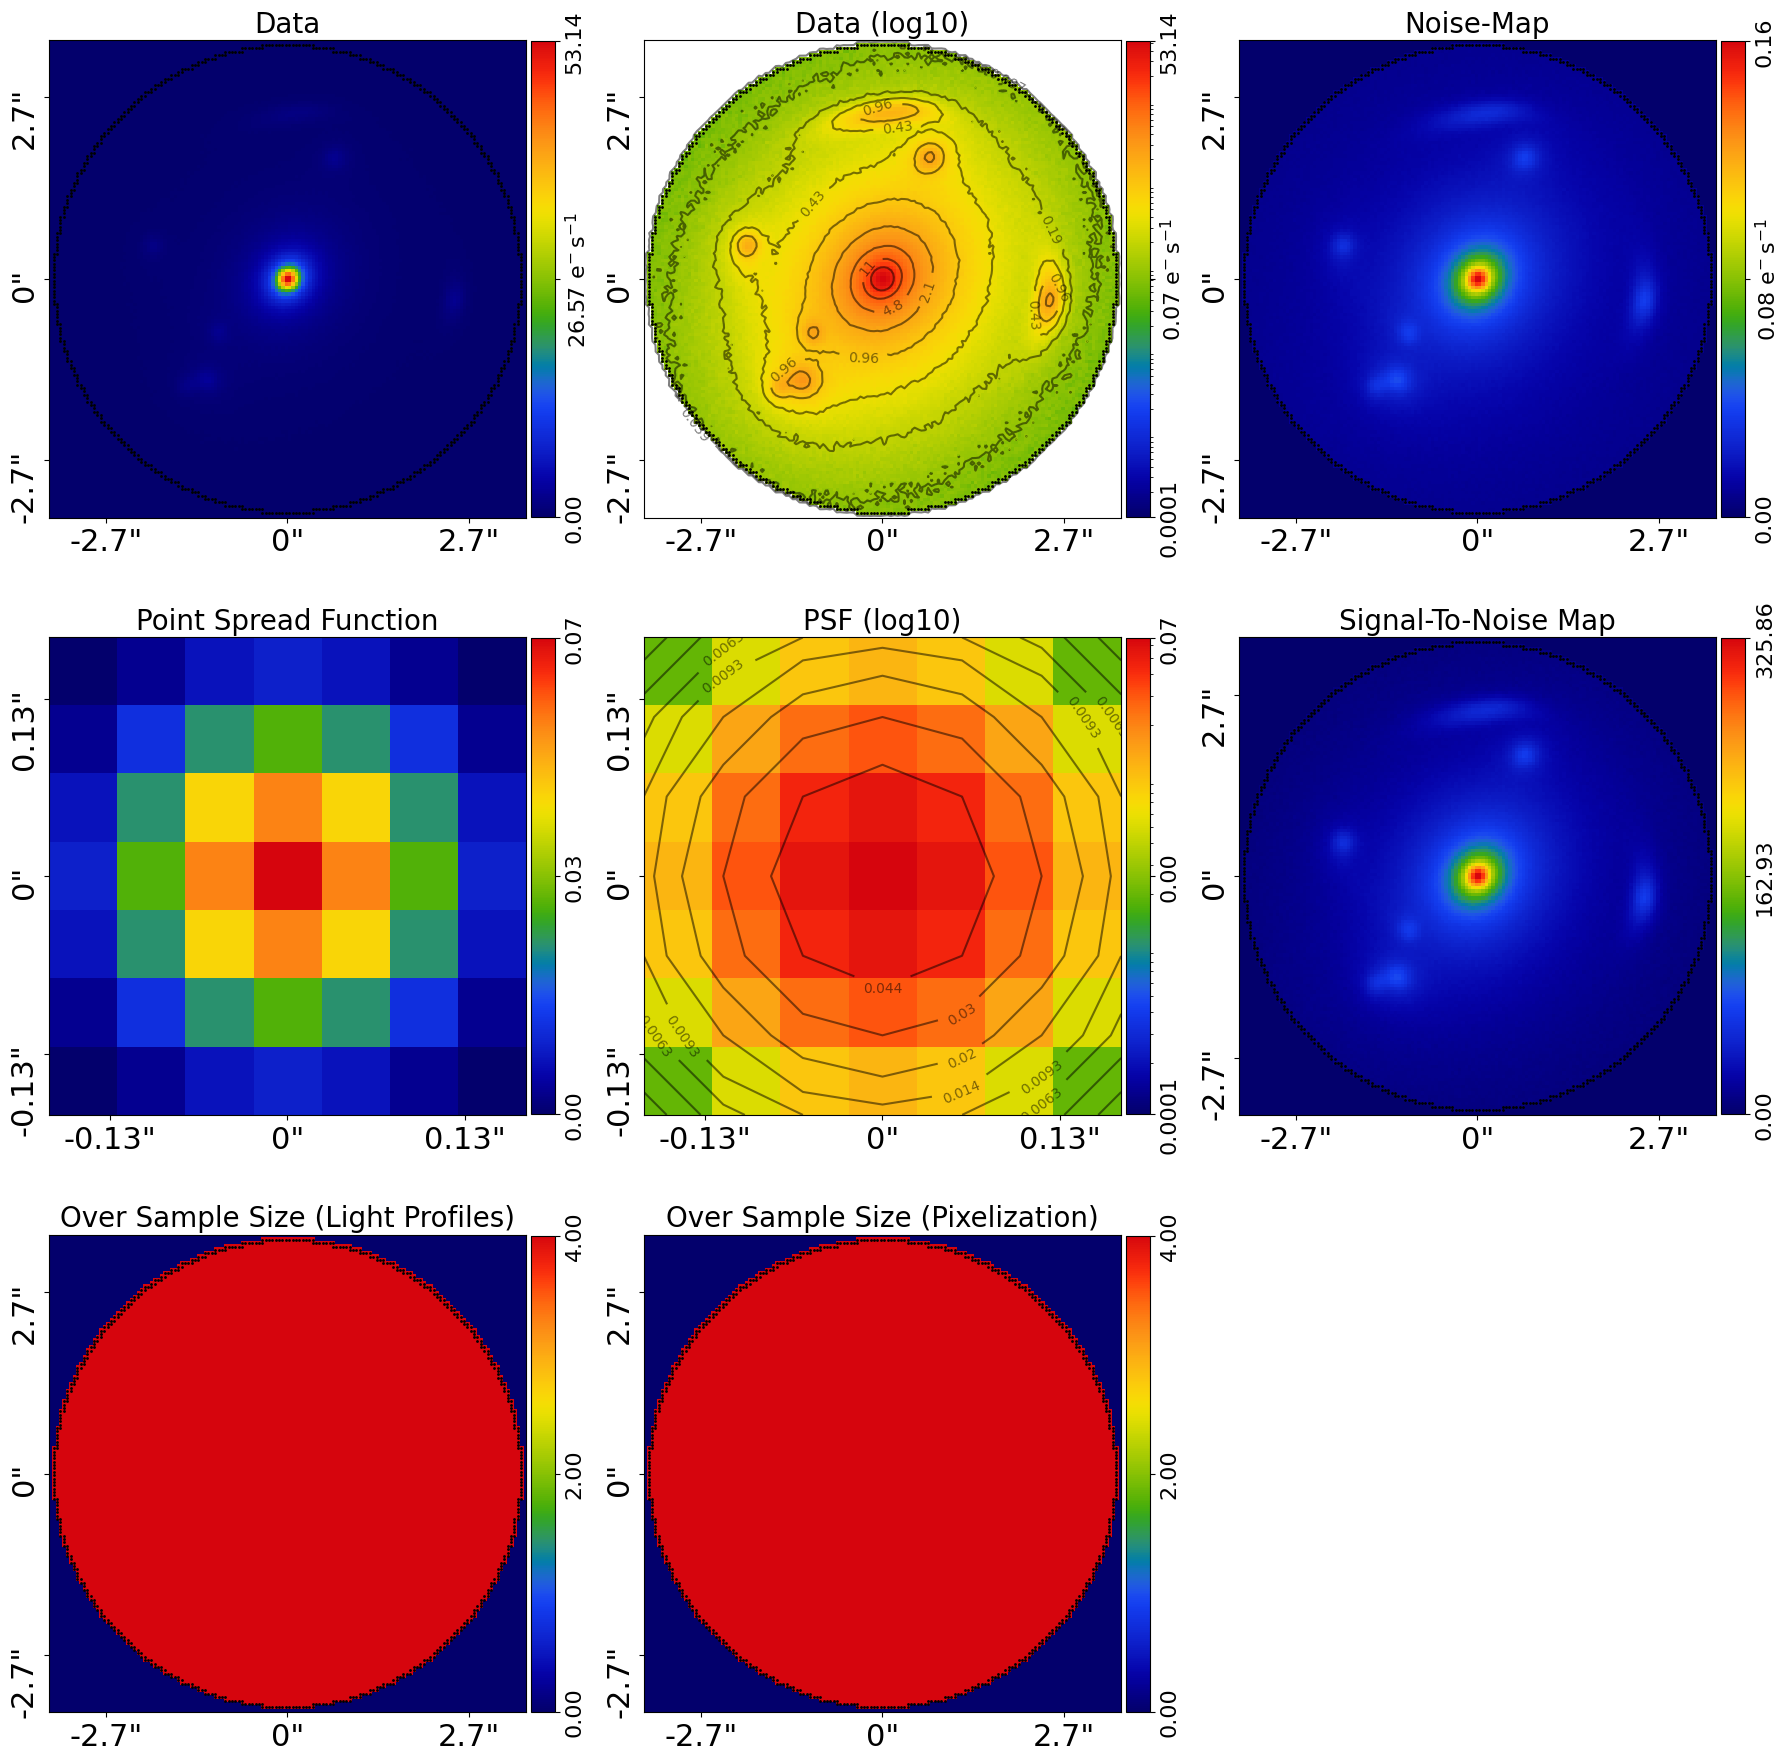

In [3]:
dataset = al.Imaging.from_fits(
    data_path      = Path("mocks") / "mock_image.fits",
    noise_map_path = Path("mocks") / "mock_noise.fits",
    psf_path       = Path("mocks") / "mock_psf.fits",
    pixel_scales   = 0.05,
)
mask = al.Mask2D.circular(
    shape_native = dataset.shape_native,
    pixel_scales = dataset.pixel_scales,
    radius       = 3.5,
)
dataset = dataset.apply_mask(mask=mask)
aplt.subplot_imaging_dataset(dataset=dataset)

---
## 2. Two fit variants

Full details in `Modules/10_Cluster_Computing/scripts/fit_example_group_scale.py`.

**Variant 1 — BGG + shear only (~15 params):**

| Component | Profile |
|---|---|
| BGG light | `al.lp.Sersic` (centre, ell_comps, intensity, R_e, n) |
| BGG mass | `al.mp.Isothermal` (centre tied to BGG bulge) |
| Shear | `al.mp.ExternalShear` |
| Source | `al.lp.SersicCore` |

Satellite light doesn't appear in the model — any residual satellite flux leaks into the image-plane residuals.

**Variant 2 — BGG + 3 satellites (~25 params):**

Adds 3 satellite galaxies with:
- **Centres FIXED** at their photometric positions (from `mock_truth.json`). In practice you'd get these from a pre-fit of just the lens-plane galaxies with no source model.
- Each satellite has a `SersicBulge` (light, fully free) + `IsothermalSph` mass (spherical — only θ_E free). Each satellite contributes **6 free params** (5 for light + 1 for mass).

The *fixed centres* are the key — lets the 3 satellites' masses be modeled without spending precious likelihood evaluations refitting positions we already know from photometry. This is the standard survey-scale pattern.

---
## 3. Results

Submitted via:

```bash
sbatch --export=ALL,EXAMPLE=group_scale,FIT_EXTRA_ARGS=--part=all \
    Modules/10_Cluster_Computing/scripts/submit_cannon.slurm
```

Runs both variants sequentially.

In [4]:
show_result("bgg_shear_only_fit")

(no results for stage 'bgg_shear_only_fit')


In [5]:
show_result("bgg_plus_satellites_fit")

(no results for stage 'bgg_plus_satellites_fit')


---
## 3.1 Truth-anchored validation — the working baseline (2026-04-29)

The two freely-fit variants above (`bgg_shear_only`, `bgg_plus_satellites`)
**did not converge** in three Cannon attempts (LEARNING_LOG 2026-04-24,
v1/v2/v3 all stalled in burn-in over 5+ hours each). Symptom: Nautilus
`f_live = 1.0` for the duration — the chain never compresses the prior
volume.

To diagnose whether this is a **search-space-exploration** failure (the
chain can't find the truth basin from wide priors) or a **model-space
representability** failure (PyAutoLens's R5 architecture genuinely
can't fit this group system), we ran a third variant:

`truth_anchored` — same architecture as `bgg_plus_satellites` but with
ALL priors set as tight Gaussians ($\sigma \sim 0.05$) centred on the
`mock_truth.json` values. If the truth basin is reachable from a chain
constrained near it, the fit converges cleanly; if not, the model-space
itself is the bottleneck.


### `truth_anchored_fit`
- log evidence: **44699.80**
- χ²/N = **1.025**
- max |normalized residual| = **4.50 σ**

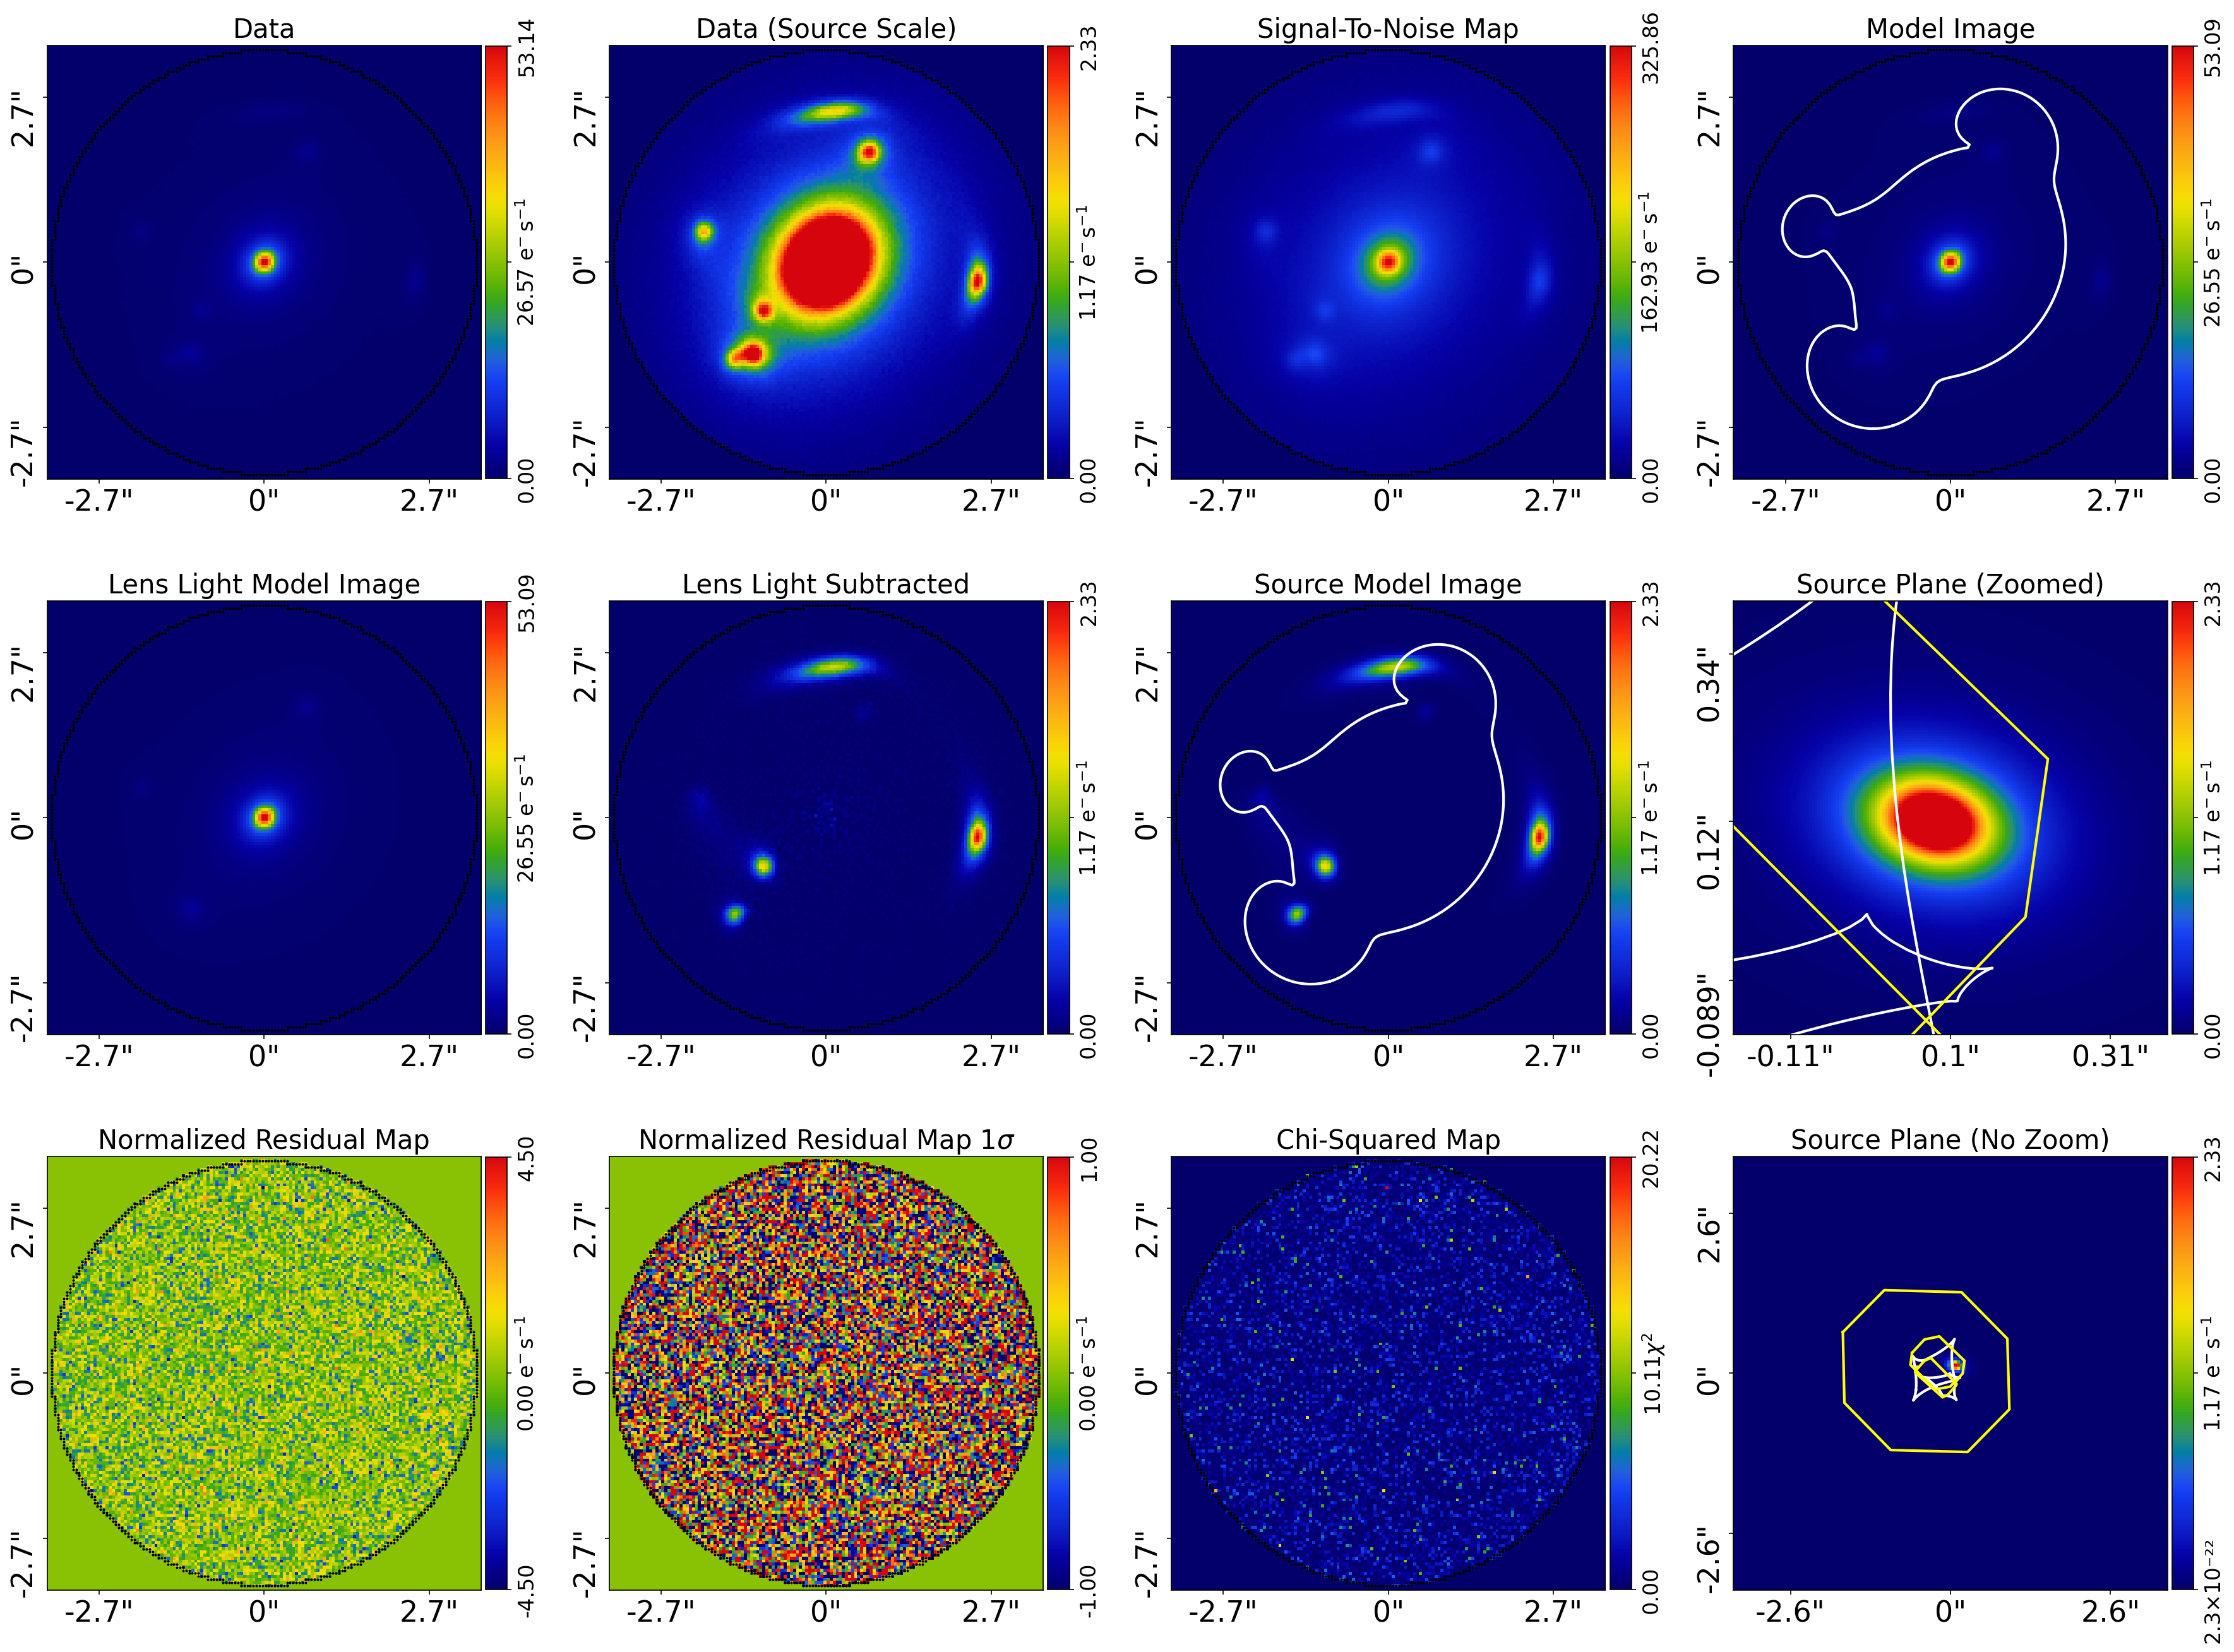

In [6]:
show_result("truth_anchored_fit")


### Verdict — `truth_anchored` PASSED

| Metric | Value | Threshold |
|---|---|---|
| log_Z | 44699.80 | — |
| χ²/N | **1.025** | PASS (≤ 1.3) |
| max\|res\| | **4.50σ** | PASS (≤ 6σ) |
| Residual structure | clean white-noise | no coherent ring/arc |
| Wall time (Cannon) | **1h 05m** | (vs. 5h+ stalls for freely-fit) |

The model space CAN fit this group-scale system. The freely-fit failures
were **search-space-exploration**, not model representability. PyAutoLens's
single-plane multi-galaxy architecture (BGG SIE + 3 satellite IsoSph + source)
correctly represents the truth lens system; Nautilus just couldn't find the
truth basin starting from wide priors in a 30-param landscape with strong
satellite-mass / BGG-mass / shear degeneracies.

### What this implies for next steps

1. **The truth-anchored result is a publishable model**: when truth is
   available (mocks, or real data with strong priors from photometry +
   kinematics + spectroscopy), this configuration converges.
2. **For genuinely-blind fitting, build a SLaM-style staged chain** that
   walks Nautilus from wide priors to a posterior near truth via
   intermediate stages with progressively tighter priors. The first
   attempt at this (`staged_satellites`, Cannon job 9212864) stalled
   in Stage 1 because the BGG-only mask radius (1.7″) cut into the BGG
   light profile (`R_e = 0.9″`) too aggressively. Future revision
   should use a wider Stage 1 mask + explicit satellite-light models.
3. **The `bgg_shear_only` variant doesn't converge from wide priors at
   all** — even with truth-seeded BGG priors, three satellite mass
   perturbations at three distinct positions cannot be absorbed into a
   single 2-parameter shear (Limousin et al. 2007's diagnostic for when
   group-scale models break down).

### Why this matters for the broader workflow

The truth-anchored validation pattern is now a documented diagnostic
tool. Whenever a freely-fit Cannon job stalls, the next experiment is
to run the same architecture with truth-anchored priors — this
distinguishes search failures from model failures cleanly. See
`Modules/10_Cluster_Computing/HANDOFF_2026_04_29.md` §9 for the
interpretation tree, and the analogous `R5_truth` work on the
compound-lens zoo (`Examples/compound_lens_zoo/02_compound_lens_ladder.ipynb` §13).


---
## 4. Comparison (post-Cannon)

**As of 2026-04-29, only `truth_anchored` (§3.1 above) has produced a clean,
converged fit.** The three freely-fit attempts (`bgg_shear_only` v1/v2/v3 +
`bgg_plus_satellites`) all stalled in burn-in. Filling in the table below
requires either running a SLaM-style staged chain (future work) or running
each freely-fit variant for >24h with a high `n_live` and accepting the
likely-non-convergent result for comparison.

| | BGG + shear | BGG + satellites |
|---|---|---|
| log_Z | ___ | ___ |
| χ²/N | ___ | ___ |
| max\|res\| | ___ σ | ___ σ |
| n_params | ~15 | ~25 |
| Chi² map at satellite positions | ___ | ___ |
| Residual arc kinks at satellite positions | ___ | ___ |

### What pedagogically to expect

- **BGG + shear alone** will leave visible residuals precisely at the three satellite positions — local arc-shape deformations that external shear (a global quadrupole) cannot mimic.
- **BGG + satellites** should flatten those residuals. Each satellite's recovered `einstein_radius` posterior is the test: non-zero posteriors well-separated from 0 mean the satellite is resolved, whereas a satellite rail-pinned at 0 means the data doesn't support its mass (absorbable into shear).
- The Bayes factor $e^{\text{ΔlogZ}}$ quantifies the "do the satellites earn their parameters" question.

### Connection to cluster lensing

In real clusters (100+ member galaxies), you can't free every satellite's θ_E. The survey-scale approach uses a **scaling relation** — each satellite's mass is a function of its luminosity (or stellar mass) and a few global parameters. This notebook ends with the simpler 3-satellite case; Module 10's cluster-computing work extends toward the full cluster regime.

---

## 5. Exercises

1. **How small can a satellite's mass be and still be resolvable?** Regenerate the mock (`mocks/generate_mock.py`) with satellite `einstein_radius` values of 0.1, 0.2, 0.3, 0.5. Refit and compare θ_E posteriors. At what θ_E does the posterior rail-pin at 0?

2. **Free the satellite centres.** Take Variant 2 but release the centre priors to `GaussianPrior(truth, 0.1″)`. Does the fit still converge cleanly? By how much does the posterior on each satellite's θ_E broaden?

3. **Scaling relation.** Assume a Faber-Jackson-like $\theta_E \propto L^{1/2}$ and fit a two-parameter scaling (normalization + slope) instead of 3 independent θ_E values. How does log_Z compare? (This is a mini-version of what survey pipelines do.)

---

## References

- Bolton+06, Auger+10 — SLACS lens sample modelling with BGG + satellites.
- Limousin+07, Jullo+07 — Lenstool cluster models with scaling relations.
- `autolens_workspace_latest/scripts/imaging/features/extra_galaxies/modeling.py` — the fixed-centre multi-galaxy pattern in PyAutoLens.
- Examples/compound_lens/ — multi-plane comparison (different redshifts).

---

*Learning to Autolens — Examples / group_scale / 01*  
*Rodrigo Córdova Rosado, Harvard CfA*